In [ ]:
---
# 📊 Partie 2 — Visualisation DVF

> Vous avez exploré le dataset DVF avec Pandas. Passons maintenant à la **visualisation**.  
> Objectif : transformer vos analyses en graphiques clairs et lisibles.

---

## 🔧 Setup — À exécuter en premier


In [2]:
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

viz = pd.read_csv("sample_dvf.csv")

""" df = pd.read_csv('data/sample_dvf.csv')
df['date_mutation'] = pd.to_datetime(df['date_mutation'])
df['mois'] = df['date_mutation'].dt.month
df['prix_m2'] = (df['valeur_fonciere'] / df['surface_reelle_bati']).round(2)
df['prix_m2'] = df['prix_m2'].where((df['prix_m2'] >= 100) & (df['prix_m2'] <= 30000))

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
print('Setup OK')
print(f'Dataset : {df.shape[0]:,} lignes x {df.shape[1]} colonnes') """

" df = pd.read_csv('data/sample_dvf.csv')\ndf['date_mutation'] = pd.to_datetime(df['date_mutation'])\ndf['mois'] = df['date_mutation'].dt.month\ndf['prix_m2'] = (df['valeur_fonciere'] / df['surface_reelle_bati']).round(2)\ndf['prix_m2'] = df['prix_m2'].where((df['prix_m2'] >= 100) & (df['prix_m2'] <= 30000))\n\nsns.set_theme(style='whitegrid')\nplt.rcParams['figure.dpi'] = 100\nprint('Setup OK')\nprint(f'Dataset : {df.shape[0]:,} lignes x {df.shape[1]} colonnes') "

In [27]:
viz.info()
viz.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unnamed: 0                 5000 non-null   int64  
 1   id_mutation                5000 non-null   object 
 2   date_mutation              5000 non-null   object 
 3   nature_mutation            5000 non-null   object 
 4   valeur_fonciere            4902 non-null   float64
 5   commune                    5000 non-null   object 
 6   surface_reelle_bati        4595 non-null   float64
 7   nombre_pieces_principales  4766 non-null   float64
 8   type_local                 4885 non-null   object 
 9   code_postal                5000 non-null   float64
 10  longitude                  4834 non-null   float64
 11  latitude                   4857 non-null   float64
 12  code_departement           5000 non-null   int64  
dtypes: float64(6), int64(2), object(5)
memory usage:

,Unnamed: 0,valeur_fonciere,surface_reelle_bati,nombre_pieces_principales,code_postal,longitude,latitude,code_departement
count,5000.000000,4.902000e+03,4595.000000,4766.000000,5000.000000,4834.000000,4857.000000,5000.000000
mean,2499.500000,3.371925e+05,61.608023,3.003777,45579.373600,1.876227,46.695468,45.579000
std,1443.520003,8.176345e+05,32.771075,1.424116,20715.563268,3.659908,2.536781,20.715443
min,0.000000,1.000000e+00,7.939199,1.000000,13001.000000,-4.495080,42.302377,13.000000
25%,1249.750000,1.806521e+05,38.462079,2.000000,33000.000000,-1.268692,44.511516,33.000000
50%,2499.500000,2.672610e+05,54.400935,3.000000,34000.000000,1.936583,46.671859,34.000000
75%,3749.250000,3.963975e+05,76.363963,4.000000,67000.000000,5.024542,48.896181,67.000000
max,4999.000000,5.000000e+07,391.962239,7.000000,75001.000000,8.197985,51.097271,75.000000


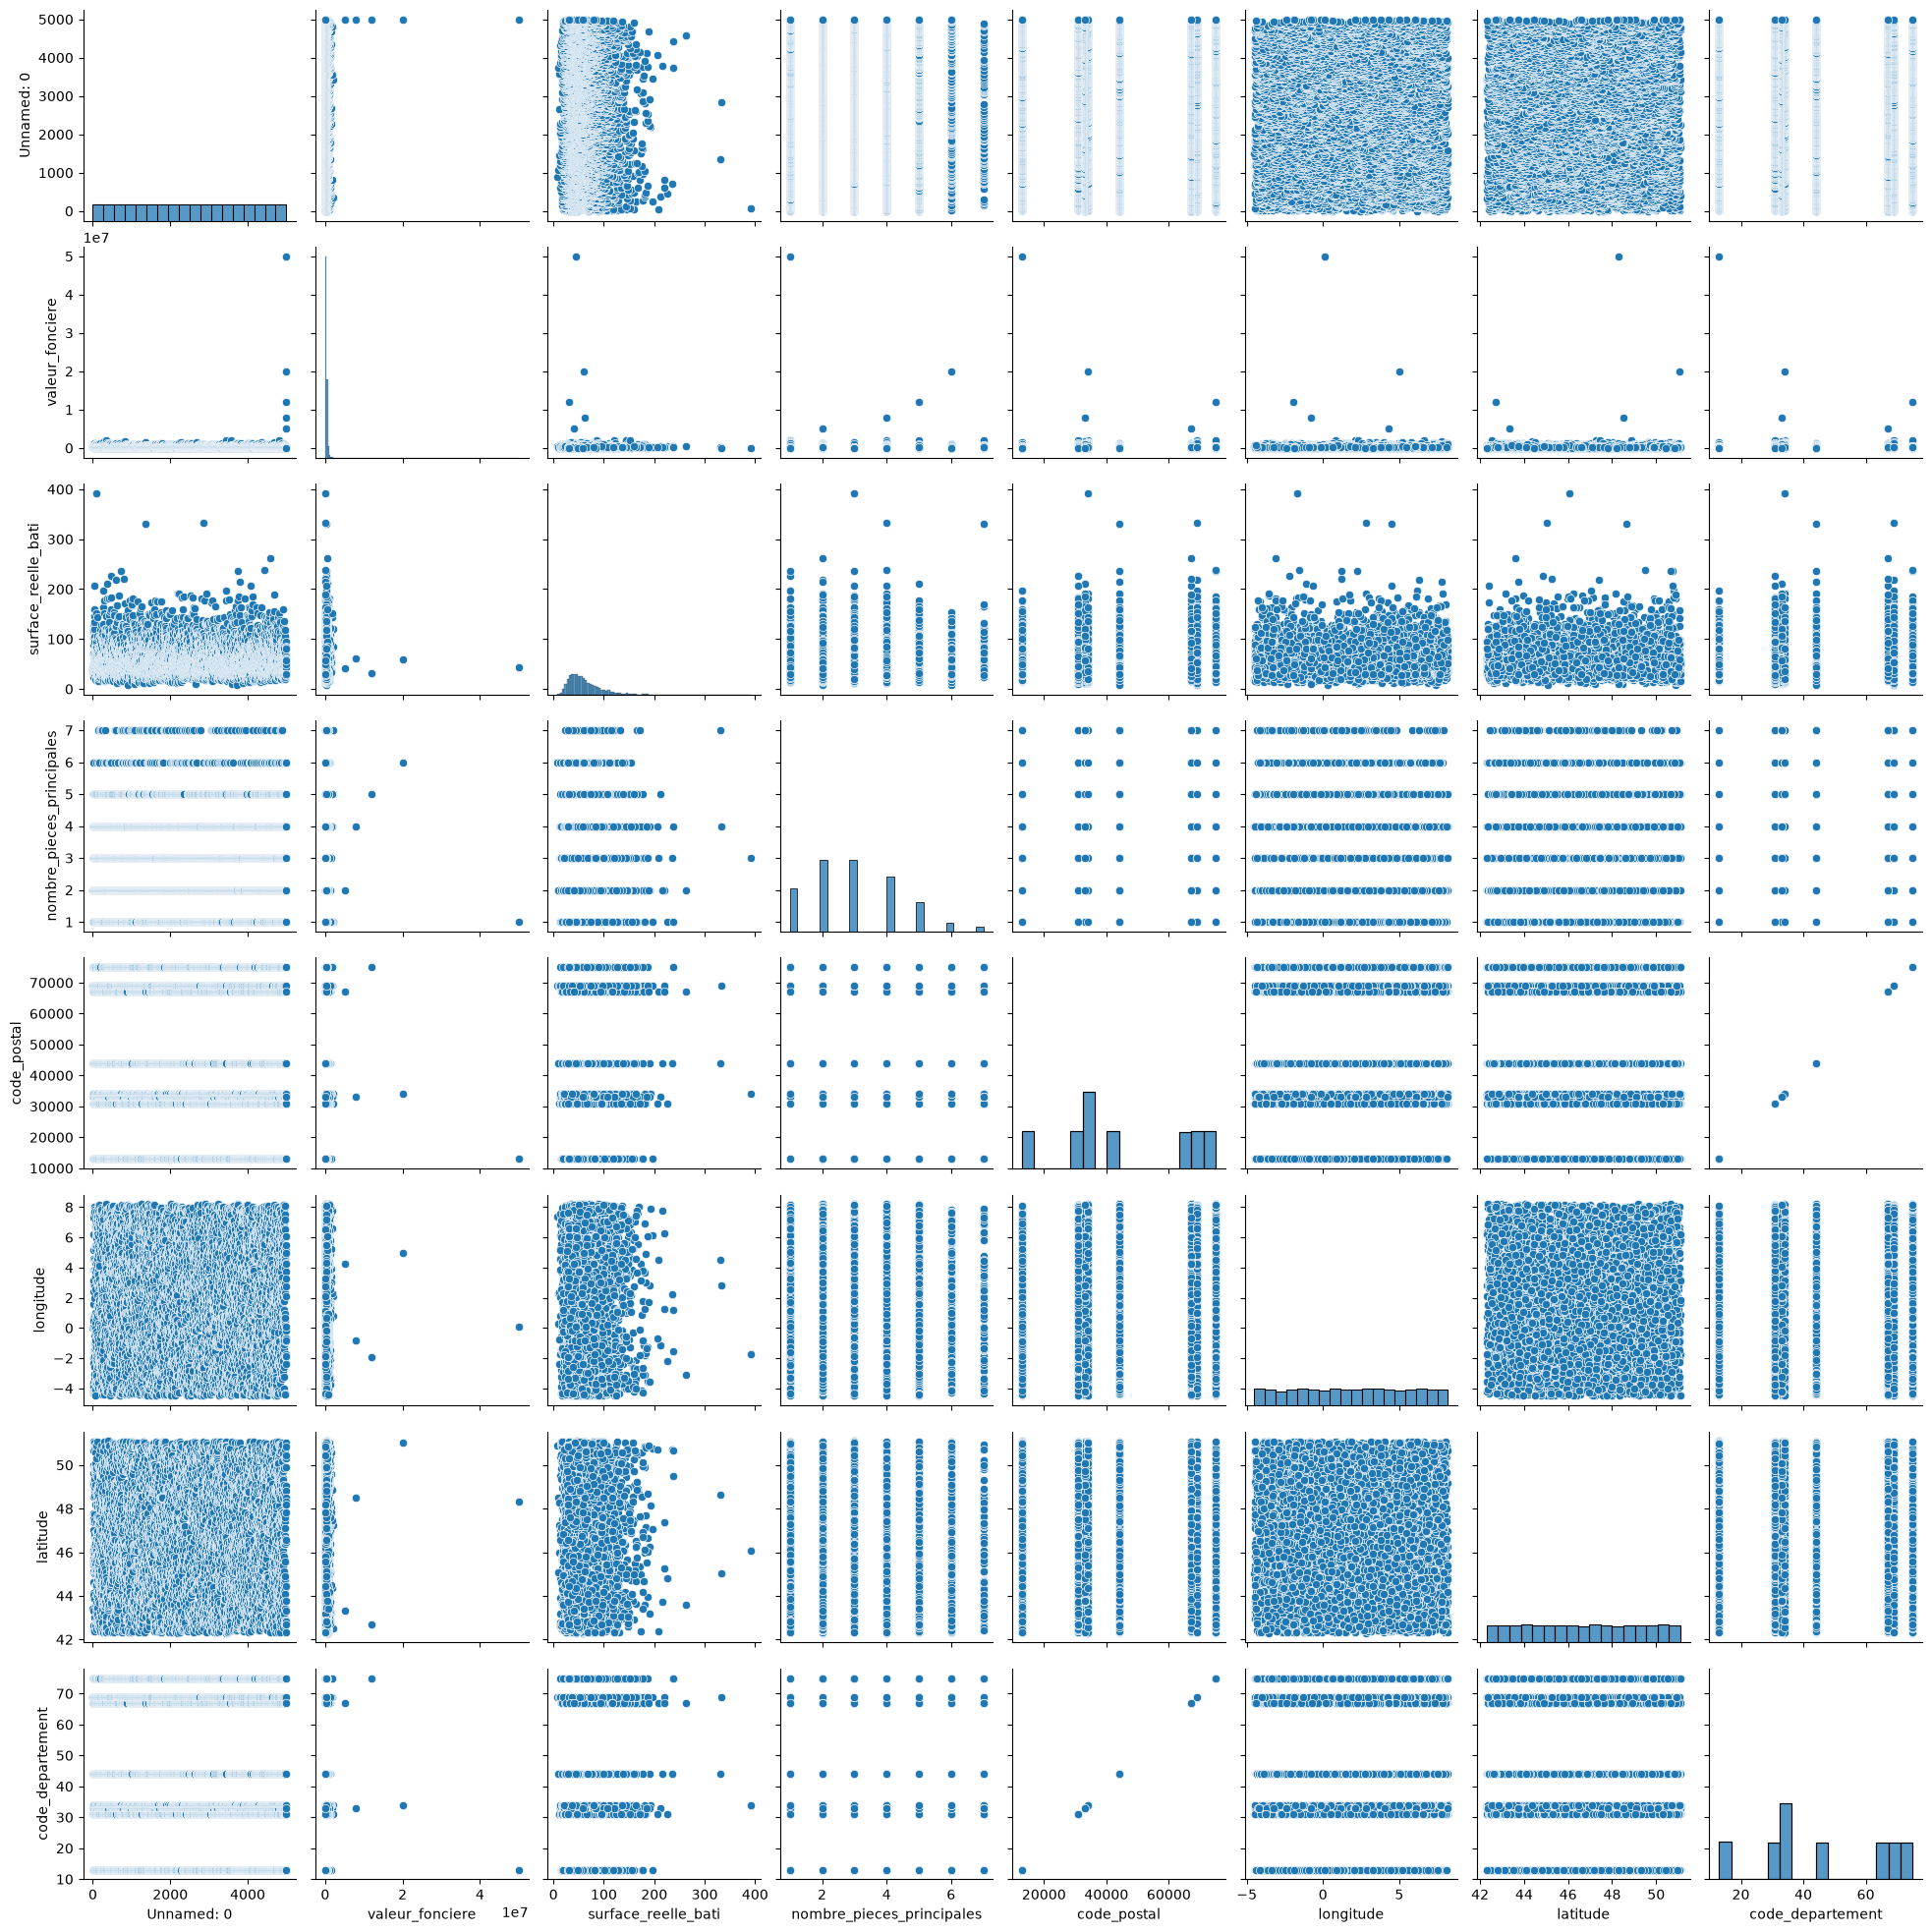

In [6]:
sns.pairplot(viz)

# ---
## 🎨 Seaborn

---

### Visu 1 — Nombre de transactions par commune

Créez un **countplot** horizontal du nombre de transactions par commune.  
- Triez par fréquence décroissante  
- Titre : `'Transactions par commune'`


Text(0.5, 0, 'nombre de transactions')

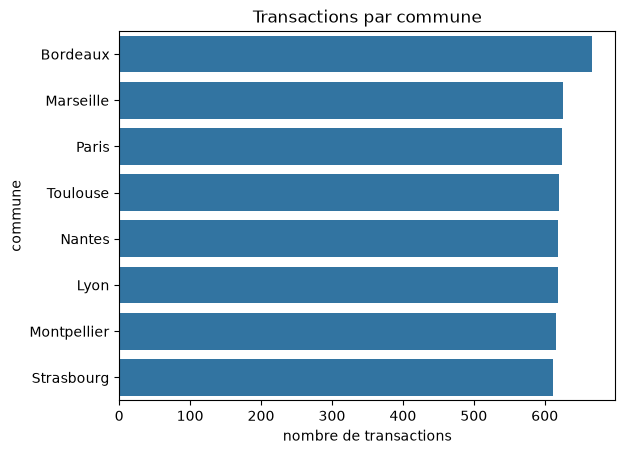

In [7]:
# Votre code ici
dec = viz.groupby("commune").size().sort_values(ascending=False).index
sns.countplot(viz, y="commune", order=dec)
plt.title("Transactions par commune")
plt.xlabel("nombre de transactions")

Text(0.5, 0, 'nombre de transactions')

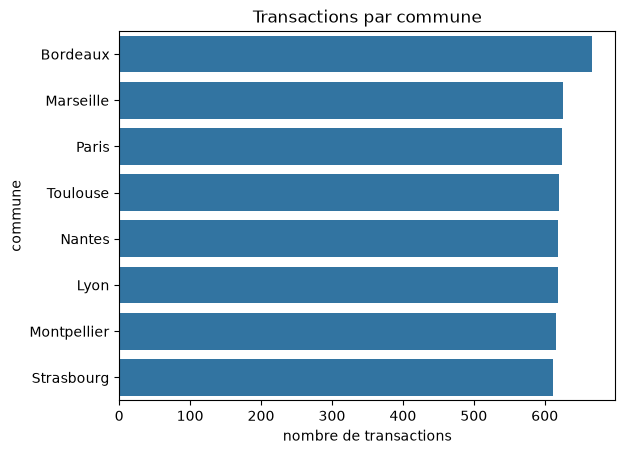

In [8]:
# Votre code ici
sns.countplot(viz, y="commune", order=viz['commune'].value_counts().index)
plt.title("Transactions par commune")
plt.xlabel("nombre de transactions")

---
### Visu 2 — Distribution des valeurs foncières

Créez un **histogramme** de la distribution des `valeur_fonciere`.  
- Limitez à des valeurs < 2 000 000 € pour éviter les outliers extrêmes  
- Ajoutez une courbe KDE  
- Ajoutez la médiane en trait rouge pointillé  
- Titre : `'Distribution des valeurs foncières'`


Text(0.5, 1.0, 'Distribution des valeurs foncières')

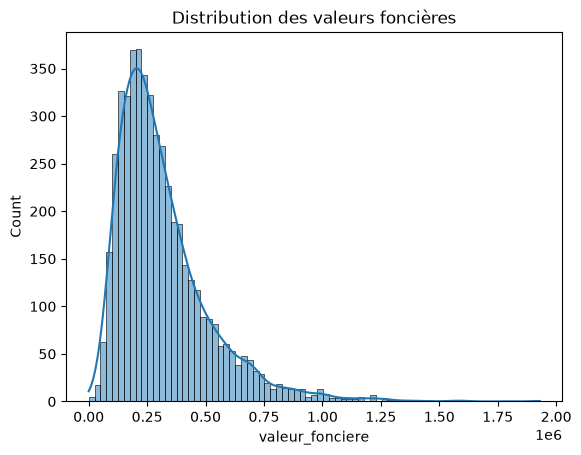

In [15]:
# Votre code ici
filtre = viz[viz["valeur_fonciere"] < 2000000]
sns.histplot(filtre, x="valeur_fonciere", kde=True)
plt.title("Distribution des valeurs foncières")

---
### Visu 3 — Prix médian par commune

Préparez un DataFrame groupé (médiane de `valeur_fonciere` par `commune`),  
puis créez un **barplot horizontal** trié par prix décroissant.  
- Titre : `'Prix médian de vente par commune'`


Text(0.5, 1.0, 'Prix médian de vente par commune')

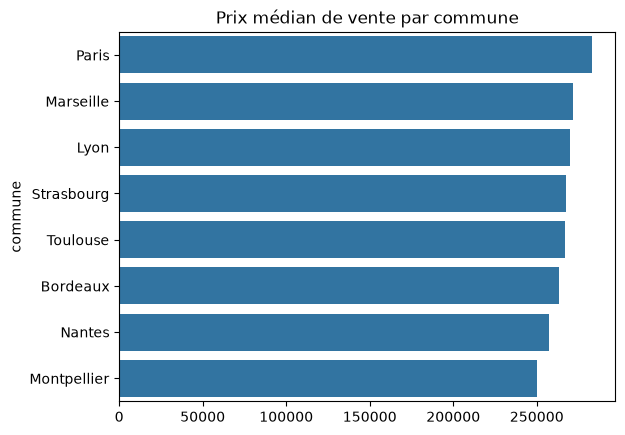

In [54]:
# Votre code ici
prix_median_commune = viz.groupby("commune")["valeur_fonciere"].median().sort_values(ascending=False)
sns.barplot(x=prix_median_commune.values, y=prix_median_commune.index)
plt.title("Prix médian de vente par commune")

In [49]:
# Votre code ici
prix_median_commune

commune
Bordeaux       263449.658539
Lyon           269717.394957
Marseille      271908.010212
Montpellier    249998.786601
Nantes         257055.831703
Paris          282782.931937
Strasbourg     267454.858757
Toulouse       266643.046670
Name: valeur_fonciere, dtype: float64

In [40]:
prix_median_commune.index

Index(['Bordeaux', 'Lyon', 'Marseille', 'Montpellier', 'Nantes', 'Paris',
       'Strasbourg', 'Toulouse'],
      dtype='object', name='commune')

In [41]:
prix_median_commune.values

array([263449.65853854, 269717.39495671, 271908.01021183, 249998.78660074,
       257055.83170296, 282782.93193656, 267454.85875748, 266643.04667001])

---
### Visu 4 — Distribution des prix par type de bien

Créez un **boxplot** comparant la distribution de `valeur_fonciere`  
entre les différents `type_local` (Maison, Appartement, etc.).  
- Filtrez les valeurs < 1 500 000 € pour la lisibilité  
- Faites pivoter les labels à 30°  
- Titre : `'Valeur foncière par type de bien'`


In [ ]:
# Votre code ici
filtre_valeur_fonciere = viz.valeur_fonciere < 1500000
sns.boxplot


In [64]:
viz.valeur_fonciere

0       109895.256545
1       136610.397410
2       338842.726864
3       132677.414245
4       523127.543909
            ...      
4995       100.000000
4996       200.000000
4997        50.000000
4998        10.000000
4999         1.000000
Name: valeur_fonciere, Length: 5000, dtype: float64

In [69]:
viz.valeur_fonciere < 1500000

0       True
1       True
2       True
3       True
4       True
        ... 
4995    True
4996    True
4997    True
4998    True
4999    True
Name: valeur_fonciere, Length: 5000, dtype: bool

In [63]:
viz.["valeur_fonciere"] < 1500000

SyntaxError: invalid syntax (653257061.py, line 1)

In [57]:
sns.boxplot(viz, orient=30)

ValueError: `orient` must start with 'v' or 'h' or be None, but `30` was passed.

---
### Visu 5 — Surface vs Valeur foncière

Créez un **scatterplot** avec :  
- X : `surface_reelle_bati` · Y : `valeur_fonciere`  
- Couleur : `type_local`  
- Filtrez les valeurs aberrantes (surface < 300 m² et valeur < 2 000 000 €)  
- Titre : `'Surface vs Valeur foncière'`


In [ ]:
# Votre code ici


---
### Visu 6 — Heatmap de corrélation

Créez une **heatmap** de corrélation sur les colonnes numériques du DVF.  
- Masquez le triangle supérieur (optionnel, indice : `np.triu`)  
- Titre : `'Corrélation — Dataset DVF'`


In [ ]:
# Votre code ici


---
## 📈 Plotly Express

---

### Visu 7 — Transactions par commune (interactif)

Créez un **bar chart interactif** du nombre de transactions par commune.  
- Colorez par commune  
- Affichez les valeurs sur les barres  
- Titre : `'Nombre de transactions par commune'`


In [ ]:
# Votre code ici


---
### Visu 8 — Répartition par type de bien

Créez un **donut chart** de la répartition des transactions par `type_local`.  
- `hole=0.4`  
- Titre : `'Répartition par type de bien'`


In [ ]:
# Votre code ici


---
### Visu 9 — Prix médian par commune (interactif)

Créez un **bar chart** du prix médian de vente par commune.  
- Colorez par commune  
- Triez par prix décroissant  
- Titre : `'Prix médian par commune'`


In [ ]:
# Votre code ici


---
### Visu 10 — Distribution des valeurs foncières par commune

Créez un **boxplot interactif** des `valeur_fonciere` par `commune`.  
- Filtrez les valeurs < 1 500 000 €  
- Affichez tous les points (`points='all'`)  
- Titre : `'Valeur foncière par commune'`


In [ ]:
# Votre code ici


---
### Visu 11 — Évolution mensuelle des transactions

Créez un **line chart** du nombre de transactions par mois.  
- X : `mois` · Y : nombre de transactions  
- Ajoutez des marqueurs  
- Titre : `'Évolution mensuelle des transactions DVF'`


In [ ]:
# Votre code ici


---
### Visu 12 — Carte géographique des transactions ⭐

Créez une **carte interactive** (`px.scatter_mapbox`) des transactions.  
- Latitude : `latitude` · Longitude : `longitude`  
- Couleur : `valeur_fonciere`  
- Taille : `surface_reelle_bati`  
- Filtrez les coordonnées aberrantes (`latitude.between(41, 52)`)  
- `mapbox_style='carto-positron'`, `zoom=4`  
- Titre : `'Carte des transactions DVF'`


In [ ]:
# Votre code ici


---
### 🏆 Défi — Analyse visuelle complète

En combinant Seaborn et Plotly, répondez visuellement à ces 3 questions :

1. **Quelle commune a les prix au m² les plus élevés ?**  
   *(Créez d'abord `prix_m2 = valeur_fonciere / surface_reelle_bati`)*

2. **Y a-t-il une saisonnalité dans les ventes ?**  
   *(Transactions par mois)*

3. **Les maisons sont-elles plus chères que les appartements ?**  
   *(Comparez les distributions)*

Pour chaque question : choisissez le graphique le plus adapté et ajoutez une phrase d'analyse.


In [ ]:
# Question 1 — Prix m2 par commune


> **Analyse :** ...

In [ ]:
# Question 2 — Saisonnalité


> **Analyse :** ...

In [ ]:
# Question 3 — Maisons vs Appartements


> **Analyse :** ...